# Handling Class Imbalance

In this notebook, we explore two common techniques for handling severe class imbalance: **Class Weighting** and **SMOTE** (Synthetic Minority Over-sampling Technique).

In [1]:
import sys
import os
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.data_preprocessing import preprocess_pipeline
from src.feature_engineering import apply_smote, get_class_weights

import warnings
warnings.filterwarnings('ignore')

## 1. The Danger of Data Leakage with SMOTE

**Data leakage** occurs when information from outside the training dataset is used to create the model. 

**Why applying SMOTE before Train-Test splitting is bad:**
SMOTE synthesizes new examples by interpolating between existing minority instances. If we apply SMOTE *before* splitting the data, the algorithm uses test instances to generate synthetic training instances. 

When we then split the data, the test set is no longer entirely unseen. The model has indirectly "peeked" at the test data during training because the synthetic instances are heavily correlated with the test instances. This artificially inflates performance metrics and gives a false sense of security; the model will likely perform poorly on truly unseen, real-world data.

**Rule of Thumb:** Any transformation that learns from data (Scalers, PCA, SMOTE) must be fit/applied **ONLY on the training set**. The test set must be left exactly as it is to represent real-world distribution.

## 2. Load Preprocessed Data

In [2]:
raw_data_path = '../data/raw/creditcard.csv'
X_train, X_test, y_train, y_test = preprocess_pipeline(raw_data_path)

print("\nOriginal Training Class Distribution:")
orig_train_counts = Counter(y_train)
print(f"Normal (0): {orig_train_counts[0]}")
print(f"Fraud (1): {orig_train_counts[1]}")

print("\nTest Class Distribution (Unchanged):")
test_counts = Counter(y_test)
print(f"Normal (0): {test_counts[0]}")
print(f"Fraud (1): {test_counts[1]}")

Loading data...


Cleaning data...


Separating features and target...
Splitting data into train and test sets...


Scaling features...



Original Training Class Distribution:
Normal (0): 226602
Fraud (1): 378

Test Class Distribution (Unchanged):
Normal (0): 56651
Fraud (1): 95


## 3. Approach 1: SMOTE (Data-level)

Let's apply SMOTE strictly to the training data. The original test distribution will remain untouched.

In [3]:
X_train_smote, y_train_smote = apply_smote(X_train, y_train, random_state=42)

print("Training Class Distribution After SMOTE:")
smote_counts = Counter(y_train_smote)
print(f"Normal (0): {smote_counts[0]}")
print(f"Fraud (1): {smote_counts[1]}")

Training Class Distribution After SMOTE:
Normal (0): 226602
Fraud (1): 226602


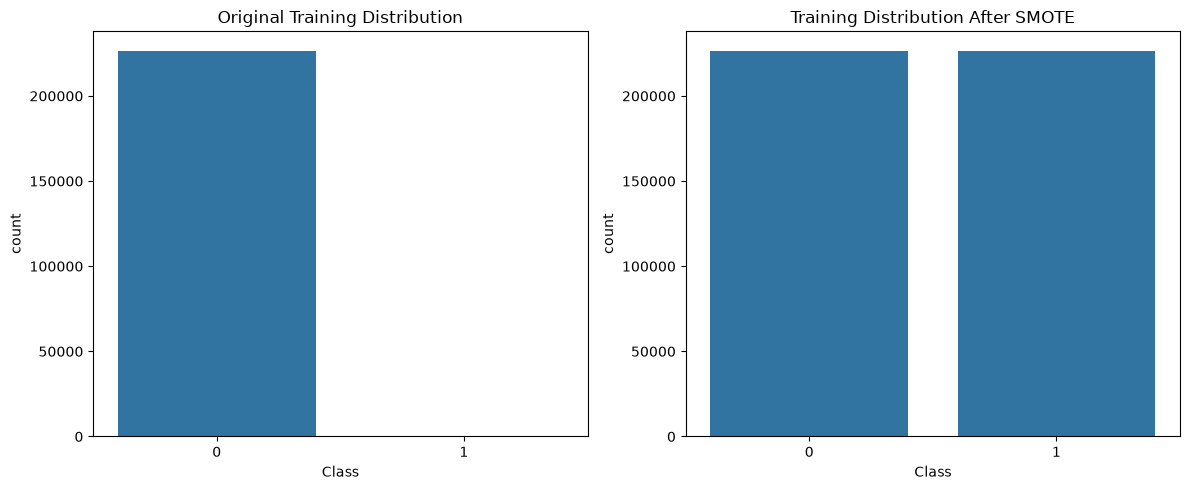

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Original Training Distribution')

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title('Training Distribution After SMOTE')

plt.tight_layout()
plt.show()

## 4. Approach 2: Class Weighting (Algorithm-level)

Instead of creating synthetic data, we can instruct our machine learning algorithms (like Logistic Regression or Random Forest) to pay more attention to the minority class by applying heavier penalties for misclassifying it.

We can calculate these weights using a heuristic inversely proportional to class frequencies.

In [5]:
weights = get_class_weights(y_train)
print(f"Class Weights calculated:\nClass 0: {weights[0]:.4f}\nClass 1: {weights[1]:.4f}")

Class Weights calculated:
Class 0: 0.5008
Class 1: 300.2381


## 5. Conclusion

Which method is better? There is no universally "best" approach. SMOTE can introduce noise if synthetic examples bridge the boundary between classes inappropriately. Class weighting is simpler and preserves the original data distribution, but might not be enough for extremely complex decision boundaries.

In the next stages, we will **experimentally compare both approaches** using robust evaluation metrics to see which performs better for our specific dataset.